In [16]:
import os
import json

def load_ministry_texts(directory):

    ministries = {}

    for file in os.listdir(directory):
        if file.endswith(".txt"):

            path = os.path.join(directory, file)

            with open(path, "r", encoding="utf-8") as f:
                text = f.read()

            name = file.replace(".txt", "")
            ministries[name] = text

    return ministries

def load_ministry_embeddings(filename):
    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

ministries = load_ministry_texts("../data/ministry_profiles")

ministry_vectors = load_ministry_embeddings("../data/embeddings/ministry_embeddings.json")

len(ministries), len(ministry_vectors), len(ministry_vectors["Ministry_of_AYUSH_MoA_"])

(53, 53, 384)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [6]:
data = ministry_vectors.copy()

names = list(data.keys())
vectors = np.array(list(data.values()))

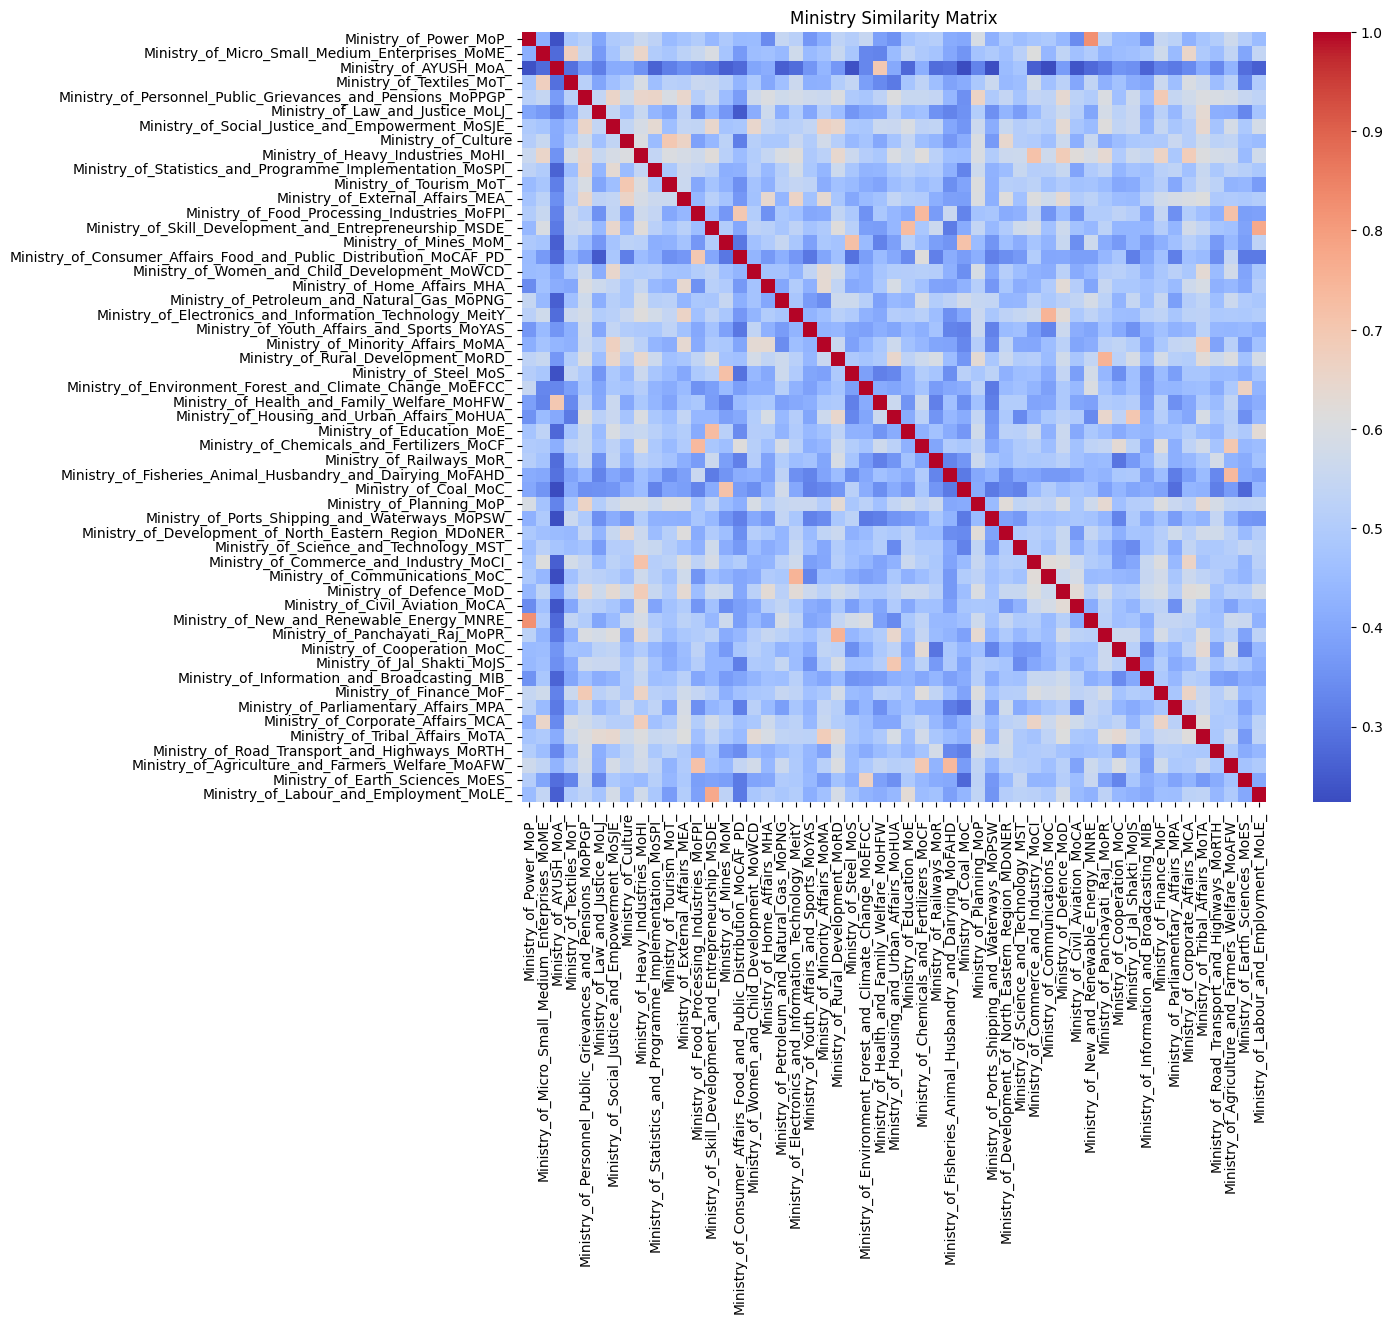

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

sim = cosine_similarity(vectors)

plt.figure(figsize=(12,10))
sns.heatmap(sim, xticklabels=names, yticklabels=names, cmap="coolwarm")
plt.title("Ministry Similarity Matrix")
plt.show()

In [8]:
# get only last _..._ part of the name for better visualization
names = [name.split("_")[-2] if name.split("_")[-1] == "" else name.split("_")[-1] for name in names]

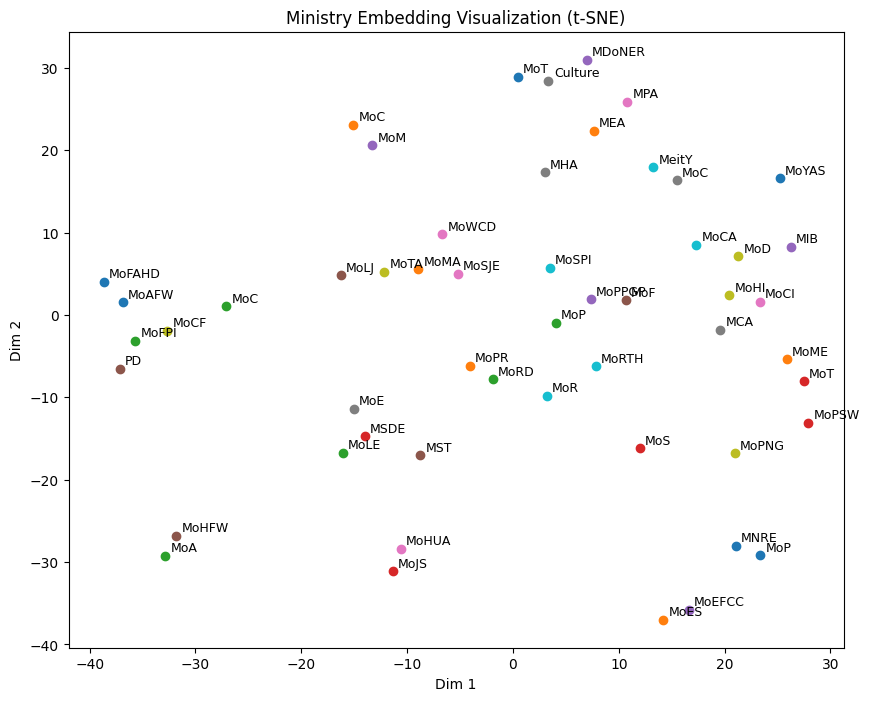

In [9]:

# reduce dimension
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
reduced = tsne.fit_transform(vectors)

# plot
plt.figure(figsize=(10,8))

for i, name in enumerate(names):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x+0.5, y+0.5, name, fontsize=9)

plt.title("Ministry Embedding Visualization (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

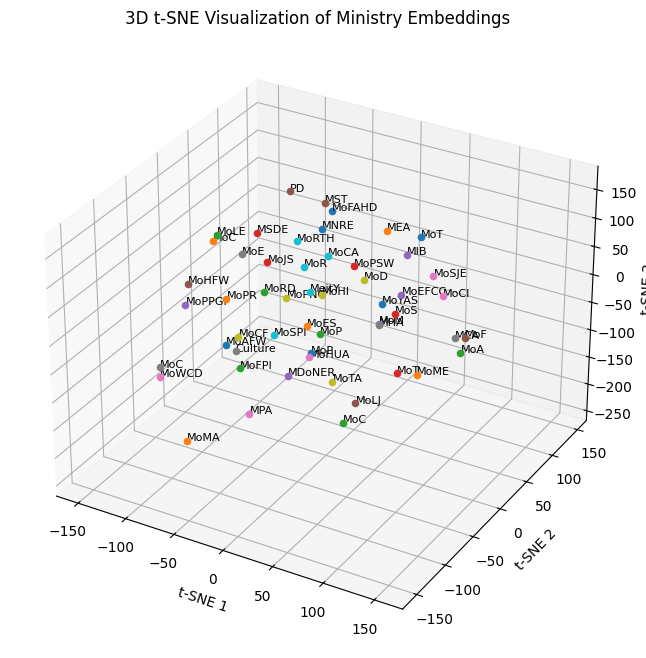

In [10]:
# --------------------------------
# t-SNE -> 3 components
# --------------------------------
tsne = TSNE(n_components=3, random_state=42, perplexity=5)

reduced = tsne.fit_transform(vectors)

# --------------------------------
# 3D Plot
# --------------------------------
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for i, name in enumerate(names):
    x, y, z = reduced[i]

    ax.scatter(x, y, z)
    ax.text(x, y, z, name, fontsize=8)

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")

ax.set_title("3D t-SNE Visualization of Ministry Embeddings")

plt.show()

Explained variance (PC1, PC2): [0.07335485 0.06743263]


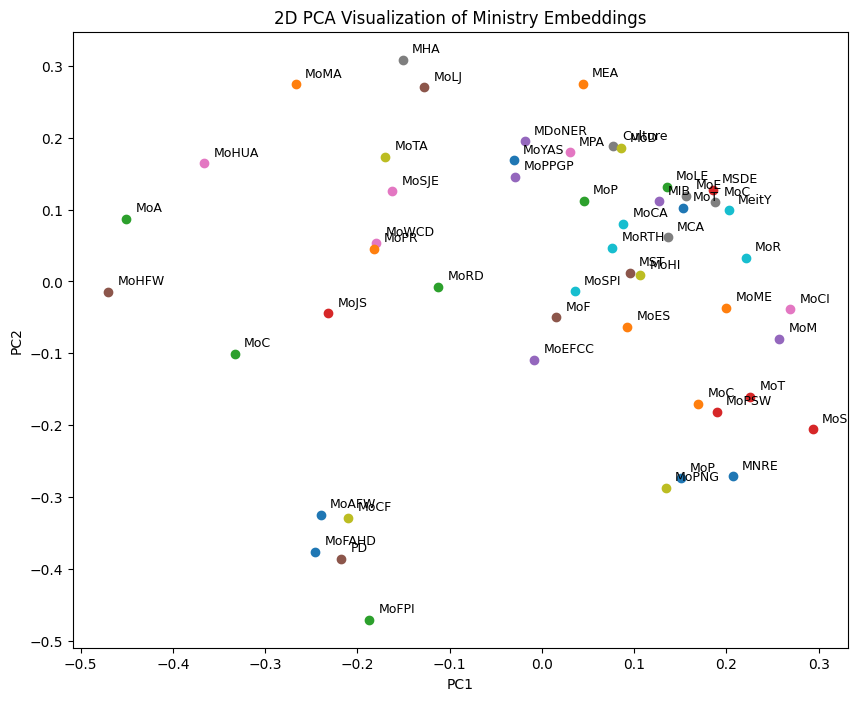

In [11]:
# --------------------------------
# PCA -> 2 components
# --------------------------------
pca_2 = PCA(n_components=2)
reduced_2 = pca_2.fit_transform(vectors)

print("Explained variance (PC1, PC2):", pca_2.explained_variance_ratio_)

plt.figure(figsize=(10,8))

for i, name in enumerate(names):
    x, y = reduced_2[i]

    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, name, fontsize=9)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Visualization of Ministry Embeddings")

plt.show()

Explained variance: [0.07335485 0.06743263 0.05420116]


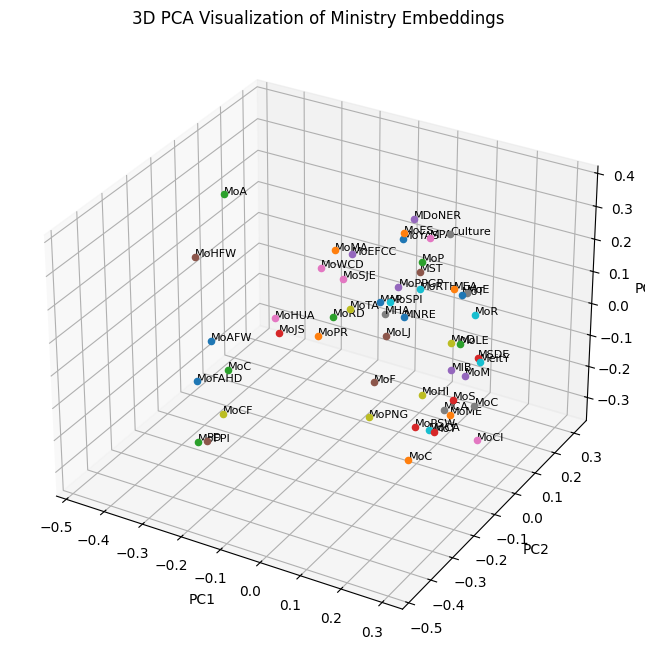

In [12]:
# --------------------------------
# PCA -> 3 components
# --------------------------------
pca = PCA(n_components=3)
reduced = pca.fit_transform(vectors)

print("Explained variance:", pca.explained_variance_ratio_)

# --------------------------------
# 3D Plot
# --------------------------------
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for i, name in enumerate(names):
    x, y, z = reduced[i]

    ax.scatter(x, y, z)
    ax.text(x, y, z, name, fontsize=8)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title("3D PCA Visualization of Ministry Embeddings")

plt.show()

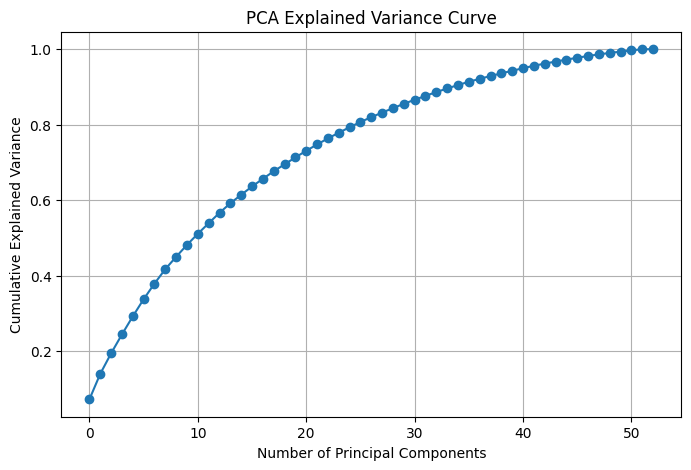

In [13]:
# --------------------------------
# Explained variance for many PCs
# --------------------------------
pca_full = PCA()
pca_full.fit(vectors)

variance = pca_full.explained_variance_ratio_
cumulative_variance = variance.cumsum()

plt.figure(figsize=(8,5))

plt.plot(cumulative_variance, marker='o')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance Curve")

plt.grid(True)

plt.show()

In [14]:
vectors.shape

(53, 384)

In [15]:
len(variance)

53